In [10]:
!pip install gurobipy


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\simor\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Step 2

### Computing and representing non-dominated solutions with 100 bricks/ 10 SRs instances

Loaded 100 bricks and 10 SR offices
Office indices (0-indexed): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape: (10, 100)
ε = 0.4  →  minimal distance = 25.630
ε = 0.5  →  minimal distance = 24.826
ε = 0.6  →  minimal distance = 23.965
ε = 0.7  →  minimal distance = 23.348
ε = 0.8  →  minimal distance = 22.684
ε = 0.9  →  minimal distance = 22.257
ε = 1.0  →  minimal distance = 21.790
ε = 1.1  →  minimal distance = 21.357
ε = 1.2  →  minimal distance = 20.935
ε = 1.3  →  minimal distance = 20.573


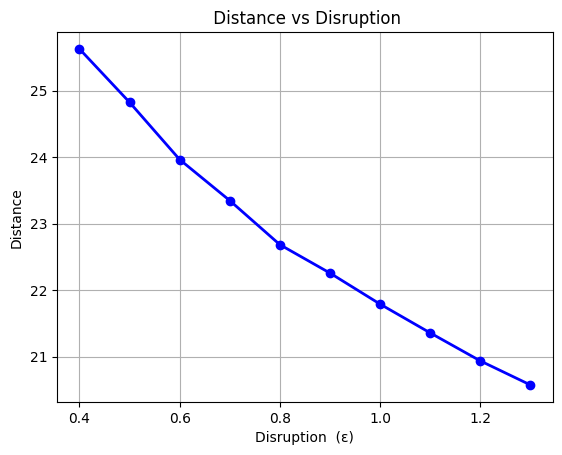

In [11]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
from pathlib import Path

CURRENT_DIR = Path.cwd()
# Read data from Excel file - first 100 rows, columns B through F
df = pd.read_excel(CURRENT_DIR/"data-100x10.xlsx", 
                   header=None, 
                   usecols="A:E",
                   nrows=100)

# Assign column names manually
df.columns = ['x-coord', 'y-coord', 'index', 'current', 'office']

# Extract parameters
Bricks = len(df)
Sales = int(df['office'].sum())  # Count number of offices (1s in office column)

print(f"Loaded {Bricks} bricks and {Sales} SR offices")

model = Model("Bricks_and_Sales_Reps_100")

### Read data from Excel
# Workloads from 'index' column
workloads = df['index'].values

# Get SR office indices (where office == 1)
office_indices = df[df['office'] == 1].index.tolist()

print(f"Office indices (0-indexed): {office_indices}")

# Extract coordinates
x_Brics = df['x-coord'].values
Y_Brics = df['y-coord'].values

# Implementation of Distance Matrix with center for each SR
# Distance from each SR office to all bricks
Distance = np.array([
    np.sqrt((x_Brics[:] - x_Brics[office_idx])**2 + 
            (Y_Brics[:] - Y_Brics[office_idx])**2) 
    for office_idx in office_indices
])

print(f"Distance matrix shape: {Distance.shape}")

# Create initial state from 'current' column
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)

for i in range(Bricks):
    sr_assignment = int(df.loc[i, 'current']) - 1  # Convert to 0-indexed
    if 0 <= sr_assignment < Sales:
        SR_initial_state[sr_assignment, i] = 1

#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.BINARY, name="SR_10")

## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
    
## Constraints Bricks
for i in range(Bricks):
    model.addConstr(sum(SR_10[j,i] for j in range(Sales)) == 1, name=f"brick_{i+1}_assignment")


# --- Objective 1 : total distance ---
distance_expr = (sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
))


# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i])/2 * workloads[i]
    for i in range(Bricks) for j in range(Sales)
)



# --- Epsilon-constraint loop ---
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    
    model.setObjective(distance_expr, GRB.MINIMIZE)
    
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →  minimal distance = {model.objVal:.3f}")
        
    #Delete old constraints
    model.remove(constr)
    model.update()

if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.grid(True)
    plt.show()

In [12]:
# After the epsilon loop, optimize one more time to get a final solution
model.optimize()

if model.status == GRB.OPTIMAL:
    print("\n" + "="*50)
    print("FINAL SOLUTION")
    print("="*50)
    
    # Iterate through each of the 10 Sales Representatives
    for j in range(Sales):
        print(f"\nSR_{j+1}:")
        
        # Calculate total workload for this SR
        total_load = sum(SR_10[j,i].X * workloads[i] for i in range(Bricks))
        
        # Print all assignments (including fractional ones for continuous variables)
        print(f"  Brick assignments:")
        assigned_count = 0
        for i in range(Bricks):
            if SR_10[j,i].X > 0.001:  # Only show non-zero assignments
                print(f"    Brick {i+1}: {SR_10[j,i].X:.4f}")
                assigned_count += 1
        
        print(f"  Total bricks assigned (>0.001): {assigned_count}")
        print(f"  Total workload: {total_load:.4f}")
    
    # Print overall statistics
    print("\n" + "="*50)
    print("OVERALL STATISTICS")
    print("="*50)
    print(f"Total distance: {model.objVal:.3f}")
    print(f"Total disruption: {disruption_expr.getValue():.4f}")


FINAL SOLUTION

SR_1:
  Brick assignments:
    Brick 1: 1.0000
    Brick 2: 1.0000
    Brick 3: 1.0000
    Brick 4: 1.0000
    Brick 5: 1.0000
    Brick 11: 1.0000
    Brick 12: 1.0000
    Brick 13: 1.0000
    Brick 14: 1.0000
    Brick 15: 1.0000
    Brick 21: 1.0000
  Total bricks assigned (>0.001): 11
  Total workload: 1.0784

SR_2:
  Brick assignments:
    Brick 6: 1.0000
    Brick 7: 1.0000
    Brick 8: 1.0000
    Brick 9: 1.0000
    Brick 16: 1.0000
    Brick 17: 1.0000
    Brick 18: 1.0000
    Brick 26: 1.0000
    Brick 27: 1.0000
    Brick 28: 1.0000
    Brick 36: 1.0000
  Total bricks assigned (>0.001): 11
  Total workload: 1.1744

SR_3:
  Brick assignments:
    Brick 10: 1.0000
    Brick 19: 1.0000
    Brick 20: 1.0000
    Brick 29: 1.0000
    Brick 30: 1.0000
    Brick 38: 1.0000
    Brick 39: 1.0000
    Brick 40: 1.0000
  Total bricks assigned (>0.001): 8
  Total workload: 0.8129

SR_4:
  Brick assignments:
    Brick 22: 1.0000
    Brick 23: 1.0000
    Brick 24: 1.0000
   

### Allowing assigning partial bricks

Loaded 100 bricks and 10 SR offices
Office indices (0-indexed): [2, 17, 29, 32, 58, 65, 72, 78, 81, 97]
Distance matrix shape: (10, 100)
ε = 0.4  →  minimal distance = 25.346
ε = 0.5  →  minimal distance = 24.359
ε = 0.6  →  minimal distance = 23.662
ε = 0.7  →  minimal distance = 23.114
ε = 0.8  →  minimal distance = 22.626
ε = 0.9  →  minimal distance = 22.157
ε = 1.0  →  minimal distance = 21.694
ε = 1.1  →  minimal distance = 21.258
ε = 1.2  →  minimal distance = 20.846
ε = 1.3  →  minimal distance = 20.448


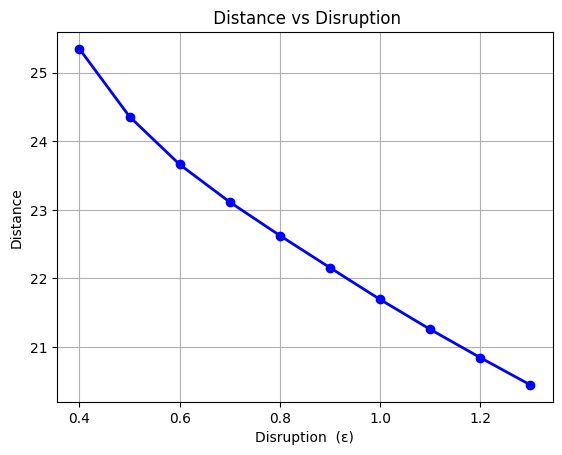

In [13]:
import pandas as pd
import numpy as np
from gurobipy import Model, GRB
import matplotlib.pyplot as plt
from pathlib import Path

CURRENT_DIR = Path.cwd()
# Read data from Excel file - first 100 rows, columns B through F
df = pd.read_excel(CURRENT_DIR/"data-100x10.xlsx", 
                   header=None, 
                   usecols="A:E",
                   nrows=100)

# Assign column names manually
df.columns = ['x-coord', 'y-coord', 'index', 'current', 'office']

# Extract parameters
Bricks = len(df)
Sales = int(df['office'].sum())  # Count number of offices (1s in office column)

print(f"Loaded {Bricks} bricks and {Sales} SR offices")

model = Model("Bricks_and_Sales_Reps_100")

### Read data from Excel
# Workloads from 'index' column
workloads = df['index'].values

# Get SR office indices (where office == 1)
office_indices = df[df['office'] == 1].index.tolist()

print(f"Office indices (0-indexed): {office_indices}")

# Extract coordinates
x_Brics = df['x-coord'].values
Y_Brics = df['y-coord'].values

# Implementation of Distance Matrix with center for each SR
# Distance from each SR office to all bricks
Distance = np.array([
    np.sqrt((x_Brics[:] - x_Brics[office_idx])**2 + 
            (Y_Brics[:] - Y_Brics[office_idx])**2) 
    for office_idx in office_indices
])

print(f"Distance matrix shape: {Distance.shape}")

# Create initial state from 'current' column
SR_initial_state = np.zeros((Sales, Bricks), dtype=float)

for i in range(Bricks):
    sr_assignment = int(df.loc[i, 'current']) - 1  # Convert to 0-indexed
    if 0 <= sr_assignment < Sales:
        SR_initial_state[sr_assignment, i] = 1

#Variables
SR_10 = model.addVars(Sales, Bricks, vtype=GRB.CONTINUOUS, name="SR_10")

## Constraints Workloads
for j in range(Sales):
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) <= 1.2,
        name=f"max_workload_10SR_{j}"
    )
    model.addConstr(
        sum(SR_10[j,i] * workloads[i] for i in range(Bricks)) >= 0.8,
        name=f"min_workload_10SR_{j}"
    )
    
## Constraints Bricks
for i in range(Bricks):
    model.addConstr(sum(SR_10[j,i] for j in range(Sales)) == 1, name=f"brick_{i+1}_assignment")


# --- Objective 1 : total distance ---
distance_expr = (sum(
    Distance[j][i] * SR_10[j,i] 
    for i in range(Bricks)
    for j in range(Sales) 
))


# --- Objective 2 : disruption ---
disruption_expr = sum(
    (SR_initial_state[j,i] - 2 * SR_initial_state[j,i] * SR_10[j,i] + SR_10[j,i])/2 * workloads[i]
    for i in range(Bricks) for j in range(Sales)
)



# --- Epsilon-constraint loop ---
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    
    model.setObjective(distance_expr, GRB.MINIMIZE)
    
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →  minimal distance = {model.objVal:.3f}")
        
    #Delete old constraints
    model.remove(constr)
    model.update()

if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.grid(True)
    plt.show()

In [14]:
# After the epsilon loop, optimize one more time to get a final solution
model.optimize()

if model.status == GRB.OPTIMAL:
    print("\n" + "="*50)
    print("FINAL SOLUTION")
    print("="*50)
    
    # Iterate through each of the 10 Sales Representatives
    for j in range(Sales):
        print(f"\nSR_{j+1}:")
        
        # Calculate total workload for this SR
        total_load = sum(SR_10[j,i].X * workloads[i] for i in range(Bricks))
        
        # Print all assignments (including fractional ones for continuous variables)
        print(f"  Brick assignments:")
        assigned_count = 0
        for i in range(Bricks):
            if SR_10[j,i].X > 0.001:  # Only show non-zero assignments
                print(f"    Brick {i+1}: {SR_10[j,i].X:.4f}")
                assigned_count += 1
        
        print(f"  Total bricks assigned (>0.001): {assigned_count}")
        print(f"  Total workload: {total_load:.4f}")
    
    # Print overall statistics
    print("\n" + "="*50)
    print("OVERALL STATISTICS")
    print("="*50)
    print(f"Total distance: {model.objVal:.3f}")
    print(f"Total disruption: {disruption_expr.getValue():.4f}")


FINAL SOLUTION

SR_1:
  Brick assignments:
    Brick 1: 1.0000
    Brick 2: 1.0000
    Brick 3: 1.0000
    Brick 4: 1.0000
    Brick 5: 1.0000
    Brick 11: 1.0000
    Brick 12: 1.0000
    Brick 13: 1.0000
    Brick 14: 1.0000
    Brick 15: 1.0000
    Brick 21: 1.0000
    Brick 24: 0.6211
  Total bricks assigned (>0.001): 12
  Total workload: 1.2000

SR_2:
  Brick assignments:
    Brick 6: 1.0000
    Brick 7: 1.0000
    Brick 8: 1.0000
    Brick 9: 1.0000
    Brick 16: 1.0000
    Brick 17: 1.0000
    Brick 18: 1.0000
    Brick 26: 1.0000
    Brick 27: 1.0000
    Brick 28: 1.0000
    Brick 36: 1.0000
    Brick 37: 0.0995
    Brick 38: 0.0739
  Total bricks assigned (>0.001): 13
  Total workload: 1.2000

SR_3:
  Brick assignments:
    Brick 10: 1.0000
    Brick 19: 1.0000
    Brick 20: 1.0000
    Brick 29: 1.0000
    Brick 30: 1.0000
    Brick 38: 0.9261
    Brick 39: 1.0000
    Brick 40: 1.0000
  Total bricks assigned (>0.001): 8
  Total workload: 0.8000

SR_4:
  Brick assignments:
   

### Adding an SR

In [17]:
# --- Imports ---
import pandas as pd
import matplotlib.pyplot as plt
from gurobipy import Model, GRB, quicksum

# --- Data loading & preprocessing ---
path = "C:/Users/simor/Documents/Simo/Master AI/MachineLearning/Decision Modeling/Pfizer_Project/distances.xlsx"

df = pd.read_excel(path, sheet_name="brick-brick", header=None)
all_distances = df.iloc[2:, 2:].reset_index(drop=True)
all_distances.columns = range(all_distances.shape[1])  # 0..21

num_bricks = all_distances.shape[0]  # should be 22
D = all_distances.to_numpy()

# Workloads (rescaled)
workloads = [0.1609, 0.1164, 0.1026, 0.1516, 0.0939, 
             0.1320, 0.0687, 0.0930, 0.2116, 0.2529, 
             0.0868, 0.0828, 0.0975, 0.8177, 0.4115, 
             0.3795, 0.0710, 0.0427, 0.1043, 0.0997, 
             0.1698, 0.2531]
workloads = [w * 1.25 for w in workloads]

# Initial states
SR1_initial_state = [0,0,0,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0]
SR2_initial_state = [0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0]
SR3_initial_state = [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,1,0,0,0,0]
SR4_initial_state = [1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1]
SR5_initial_state = [0]*num_bricks

# --- Model ---
model = Model("OptionB_Choose_5th_Column")

# Binary assignment vars
SR_1 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_1")
SR_2 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_2")
SR_3 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_3")
SR_4 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_4")
SR_5 = model.addVars(num_bricks, vtype=GRB.BINARY, name="SR_5")

# --- Column choice for SR5 ---
choose_cols = range(4, num_bricks)
z = model.addVars(choose_cols, vtype=GRB.BINARY, name="choose_col")
model.addConstr(quicksum(z[j] for j in choose_cols) == 1, name="one_column")

# Linearization of SR_5[i] * z[j]
y = model.addVars(range(num_bricks), choose_cols, vtype=GRB.BINARY, name="y")
for i in range(num_bricks):
    for j in choose_cols:
        model.addConstr(y[i, j] <= SR_5[i])
        model.addConstr(y[i, j] <= z[j])
        model.addConstr(y[i, j] >= SR_5[i] + z[j] - 1)

# --- Workload constraints ---
for (SR, name) in [(SR_1, "SR1"), (SR_2, "SR2"), (SR_3, "SR3"), (SR_4, "SR4"), (SR_5, "SR5")]:
    model.addConstr(quicksum(SR[i] * workloads[i] for i in range(num_bricks)) <= 1.2, name=f"max_workload_{name}")
    model.addConstr(quicksum(SR[i] * workloads[i] for i in range(num_bricks)) >= 0.8, name=f"min_workload_{name}")

# --- One assignment per brick ---
for i in range(num_bricks):
    model.addConstr(SR_1[i] + SR_2[i] + SR_3[i] + SR_4[i] + SR_5[i] == 1, name=f"assign_{i}")

# --- Objective 1: total distance ---
distance_expr = quicksum(
    D[i, 0] * SR_1[i] +
    D[i, 1] * SR_2[i] +
    D[i, 2] * SR_3[i] +
    D[i, 3] * SR_4[i]
    for i in range(num_bricks)
)
distance_expr += quicksum(D[i, j] * y[i, j] for i in range(num_bricks) for j in choose_cols)

# --- Objective 2: disruption ---
disruption_expr = quicksum(
    (SR1_initial_state[i] - 2 * SR1_initial_state[i] * SR_1[i] + SR_1[i] +
     SR2_initial_state[i] - 2 * SR2_initial_state[i] * SR_2[i] + SR_2[i] +
     SR3_initial_state[i] - 2 * SR3_initial_state[i] * SR_3[i] + SR_3[i] +
     SR4_initial_state[i] - 2 * SR4_initial_state[i] * SR_4[i] + SR_4[i] +
     SR5_initial_state[i] - 2 * SR5_initial_state[i] * SR_5[i] + SR_5[i]) / 2
    for i in range(num_bricks)
)

# --- Epsilon-constraint loop ---
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
pareto_points = []

for eps in epsilons:
    constr = model.addConstr(disruption_expr <= eps, name=f"eps_{eps}")
    
    model.setObjective(distance_expr, GRB.MINIMIZE)
    
    model.Params.OutputFlag = 0
    model.optimize()
    
    if model.status == GRB.OPTIMAL:
        pareto_points.append((eps, model.objVal))
        print(f"ε = {eps:>2}  →  minimal distance = {model.objVal:.3f}")
        
    #Delete old constraints
    model.remove(constr)
    model.update()

if pareto_points:
    eps_vals, costs = zip(*pareto_points)
    plt.plot(eps_vals, costs, 'o-', color='blue', linewidth=2)
    plt.xlabel("Disruption  (ε)")
    plt.ylabel("Distance")
    plt.title(" Distance vs Disruption")
    plt.grid(True)
    plt.show()